In [ ]:
# Colab already provides a CUDA-enabled PyTorch build. Do not reinstall torch.
%pip install -q kagglehub Pillow matplotlib numpy

In [1]:
import torch

cuda_available = torch.cuda.is_available()
print("CUDA available:", cuda_available)
assert cuda_available, "Enable a GPU runtime before continuing."
GPU_NAME = torch.cuda.get_device_name(0)
print("GPU:", GPU_NAME)

CUDA available: True
GPU: Tesla T4


In [2]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/chetanraje27/Digital-Evidence-GenAI.git"
PROJECT_ROOT = Path("/content/Digital-Evidence-GenAI")

if not PROJECT_ROOT.exists():
    subprocess.run(["git", "clone", REPO_URL, str(PROJECT_ROOT)], check=True)
else:
    print(f"Updating existing checkout: {PROJECT_ROOT}")
    subprocess.run(["git", "-C", str(PROJECT_ROOT), "pull", "--ff-only"], check=True)

os.chdir(PROJECT_ROOT)
print("Project root:", Path.cwd())

Project root: /content/Digital-Evidence-GenAI


In [3]:
%%writefile /content/Digital-Evidence-GenAI/src/autoencoder.py
import torch
import torch.nn as nn


class ConvolutionalAutoencoder(nn.Module):
    """
    Convolutional autoencoder for 128x128 RGB images.
    Latent is 64 x 8 x 8 = 4096 values (vs. old 32 x 8 x 8 = 2048),
    giving the decoder more information to reconstruct detail.
    """

    def __init__(self, latent_channels: int = 64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, latent_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(latent_channels),
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction

    def encode(self, x):
        return self.encoder(x)

Overwriting /content/Digital-Evidence-GenAI/src/autoencoder.py


In [4]:
%%writefile /content/Digital-Evidence-GenAI/src/train_autoencoder.py
import time
from pathlib import Path

import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt

from autoencoder import ConvolutionalAutoencoder
from ae_dataset import create_ae_dataloaders


def combined_loss(pred, target, l1_weight=0.5):
    mse = nn.functional.mse_loss(pred, target)
    l1 = nn.functional.l1_loss(pred, target)
    return (1 - l1_weight) * mse + l1_weight * l1


def train(args):
    torch.manual_seed(args.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    loaders = create_ae_dataloaders(
        args.splits_dir,
        image_size=args.image_size,
        batch_size=args.batch_size,
        num_workers=args.num_workers,
        seed=args.seed,
    )
    train_loader = loaders["train"]
    val_loader = loaders["validation"]

    model = ConvolutionalAutoencoder().to(device)
    optimizer = Adam(model.parameters(), lr=args.learning_rate)

    Path(args.checkpoint_path).parent.mkdir(parents=True, exist_ok=True)
    Path(args.history_path).parent.mkdir(parents=True, exist_ok=True)
    Path(args.curve_path).parent.mkdir(parents=True, exist_ok=True)
    Path(args.grid_path).parent.mkdir(parents=True, exist_ok=True)

    history_rows = []
    best_val_loss = float("inf")
    best_epoch = 0
    epochs_since_improvement = 0
    early_stopping_triggered = False
    first_train_loss = None
    final_train_loss = None

    start_time = time.time()

    for epoch in range(1, args.max_epochs + 1):
        epoch_start = time.time()

        model.train()
        train_loss_sum, train_batches = 0.0, 0
        for batch in train_loader:
            images = batch["image"].to(device)
            optimizer.zero_grad()
            reconstruction = model(images)
            loss = combined_loss(reconstruction, images)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item()
            train_batches += 1
        train_loss = train_loss_sum / train_batches

        model.eval()
        val_loss_sum, val_batches = 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                images = batch["image"].to(device)
                reconstruction = model(images)
                loss = combined_loss(reconstruction, images)
                val_loss_sum += loss.item()
                val_batches += 1
        val_loss = val_loss_sum / val_batches

        elapsed = time.time() - epoch_start
        print(f"Epoch {epoch:02d}/{args.max_epochs} | train={train_loss:.8f} "
              f"| validation={val_loss:.8f} | seconds={elapsed:.1f}")

        if first_train_loss is None:
            first_train_loss = train_loss
        final_train_loss = train_loss
        history_rows.append({"epoch": epoch, "train_loss": train_loss, "validation_loss": val_loss})

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_since_improvement = 0
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "validation_loss": val_loss,
            }, args.checkpoint_path)
        else:
            epochs_since_improvement += 1
            if epochs_since_improvement >= args.patience:
                early_stopping_triggered = True
                print(f"Early stopping at epoch {epoch} (no improvement for {args.patience} epochs).")
                break

    total_time = time.time() - start_time

    import csv
    with open(args.history_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["epoch", "train_loss", "validation_loss"])
        writer.writeheader()
        writer.writerows(history_rows)

    epochs = [row["epoch"] for row in history_rows]
    train_losses = [row["train_loss"] for row in history_rows]
    val_losses = [row["validation_loss"] for row in history_rows]

    plt.figure(figsize=(9, 5))
    plt.plot(epochs, train_losses, marker="o", label="train_loss")
    plt.plot(epochs, val_losses, marker="o", label="validation_loss")
    plt.axvline(best_epoch, color="green", linestyle="--", alpha=0.8, label=f"Best epoch {best_epoch}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Autoencoder Training")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(args.curve_path)
    plt.close()

    best_checkpoint = torch.load(args.checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    model.eval()

    sample_batch = next(iter(val_loader))
    sample_images = sample_batch["image"][:8].to(device)
    with torch.no_grad():
        sample_recon = model(sample_images)

    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i in range(8):
        original = sample_images[i].cpu().permute(1, 2, 0).numpy()
        recon = sample_recon[i].cpu().permute(1, 2, 0).numpy()
        axes[0, i].imshow(original.clip(0, 1))
        axes[0, i].axis("off")
        axes[1, i].imshow(recon.clip(0, 1))
        axes[1, i].axis("off")
    plt.tight_layout()
    plt.savefig(args.grid_path)
    plt.close()

    return {
        "epochs_completed": len(history_rows),
        "first_train_loss": first_train_loss,
        "final_train_loss": final_train_loss,
        "best_validation_loss": best_val_loss,
        "best_epoch": best_epoch,
        "early_stopping_triggered": early_stopping_triggered,
        "training_time_seconds": total_time,
        "checkpoint_path": str(args.checkpoint_path),
    }

Overwriting /content/Digital-Evidence-GenAI/src/train_autoencoder.py


In [5]:
import kagglehub

DATASET_HANDLE = "divg07/casia-20-image-tampering-detection-dataset"
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
downloaded_path = kagglehub.dataset_download(
    DATASET_HANDLE, output_dir=str(RAW_DATA_DIR)
)
print("Dataset location:", downloaded_path)
print("Authentic directory exists:", (RAW_DATA_DIR / "CASIA2" / "Au").is_dir())
print("Tampered directory exists:", (RAW_DATA_DIR / "CASIA2" / "Tp").is_dir())

100%|██████████| 2.56G/2.56G [00:22<00:00, 122MB/s]

Extracting files...


Dataset location: /content/Digital-Evidence-GenAI/data/raw
Authentic directory exists: True
Tampered directory exists: True


In [6]:
import csv
from pathlib import Path, PureWindowsPath

SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
split_rows = {}
for split_name in ("train", "validation", "test"):
    manifest = SPLITS_DIR / f"{split_name}.csv"
    with manifest.open(newline="", encoding="utf-8") as file:
        split_rows[split_name] = list(csv.DictReader(file))

all_rows = [row for rows in split_rows.values() for row in rows]
all_paths = [row["image_path"] for row in all_rows]
assert len(all_rows) == 12_614
assert len(set(path.casefold() for path in all_paths)) == 12_614
assert all(not Path(path).is_absolute() and not PureWindowsPath(path).is_absolute() for path in all_paths)
assert all(Path(path).suffix.casefold() != ".png" for path in all_paths)
assert all("groundtruth" not in path.casefold() for path in all_paths)
missing = [path for path in all_paths if not (PROJECT_ROOT / path).is_file()]
assert not missing, f"Missing dataset files (first five): {missing[:5]}"
print({name: len(rows) for name, rows in split_rows.items()})
print("Portable paths, unique membership, file existence, and mask exclusion: PASS")

{'train': 8830, 'validation': 1892, 'test': 1892}
Portable paths, unique membership, file existence, and mask exclusion: PASS


In [7]:
import importlib
import sys
from argparse import Namespace

sys.path.insert(0, str(PROJECT_ROOT / "src"))
import autoencoder
import train_autoencoder
importlib.reload(autoencoder)
importlib.reload(train_autoencoder)
train = train_autoencoder.train

training_args = Namespace(
    splits_dir=PROJECT_ROOT / "data" / "splits",
    checkpoint_path=PROJECT_ROOT / "checkpoints" / "best_autoencoder.pth",
    history_path=PROJECT_ROOT / "results" / "ae_training_history.csv",
    curve_path=PROJECT_ROOT / "outputs" / "ae" / "ae_training_curve.png",
    grid_path=PROJECT_ROOT / "outputs" / "ae" / "trained_reconstruction_grid.png",
    image_size=128,
    batch_size=32,
    num_workers=0,
    learning_rate=0.001,
    max_epochs=100,
    patience=10,
    seed=42,
    smoke_test=False,
)
training_summary = train(training_args)

Epoch 01/100 | train=0.05104679 | validation=0.03946661 | seconds=40.0
Epoch 02/100 | train=0.03519663 | validation=0.03441542 | seconds=40.1
Epoch 03/100 | train=0.03271766 | validation=0.02928115 | seconds=39.3
Epoch 04/100 | train=0.03100355 | validation=0.03002339 | seconds=36.7
Epoch 05/100 | train=0.02998600 | validation=0.03349989 | seconds=37.0
Epoch 06/100 | train=0.02904429 | validation=0.02531735 | seconds=36.6
Epoch 07/100 | train=0.02788614 | validation=0.02608644 | seconds=37.1
Epoch 08/100 | train=0.02756875 | validation=0.02391037 | seconds=35.9
Epoch 09/100 | train=0.02594888 | validation=0.02760960 | seconds=36.5
Epoch 10/100 | train=0.02583564 | validation=0.02553384 | seconds=36.5
Epoch 11/100 | train=0.02538108 | validation=0.02346389 | seconds=36.4
Epoch 12/100 | train=0.02508752 | validation=0.02462030 | seconds=36.6
Epoch 13/100 | train=0.02486601 | validation=0.02281999 | seconds=36.4
Epoch 14/100 | train=0.02420983 | validation=0.02250176 | seconds=36.6
Epoch 

In [8]:
required_artifacts = [
    training_args.checkpoint_path,
    training_args.history_path,
    training_args.curve_path,
    training_args.grid_path,
]
assert all(path.is_file() for path in required_artifacts)

print("GPU:", GPU_NAME)
print("Epochs completed:", training_summary["epochs_completed"])
print("First train loss:", training_summary["first_train_loss"])
print("Final train loss:", training_summary["final_train_loss"])
print("Best validation loss:", training_summary["best_validation_loss"])
print("Best epoch:", training_summary["best_epoch"])
print("Early stopping triggered:", training_summary["early_stopping_triggered"])
print("Total training time (seconds):", training_summary["training_time_seconds"])
print("Best checkpoint path:", training_summary["checkpoint_path"])

GPU: Tesla T4
Epochs completed: 100
First train loss: 0.05104679480680953
Final train loss: 0.018022317435943347
Best validation loss: 0.016852653957903384
Best epoch: 95
Early stopping triggered: False
Total training time (seconds): 3746.705034971237
Best checkpoint path: /content/Digital-Evidence-GenAI/checkpoints/best_autoencoder.pth


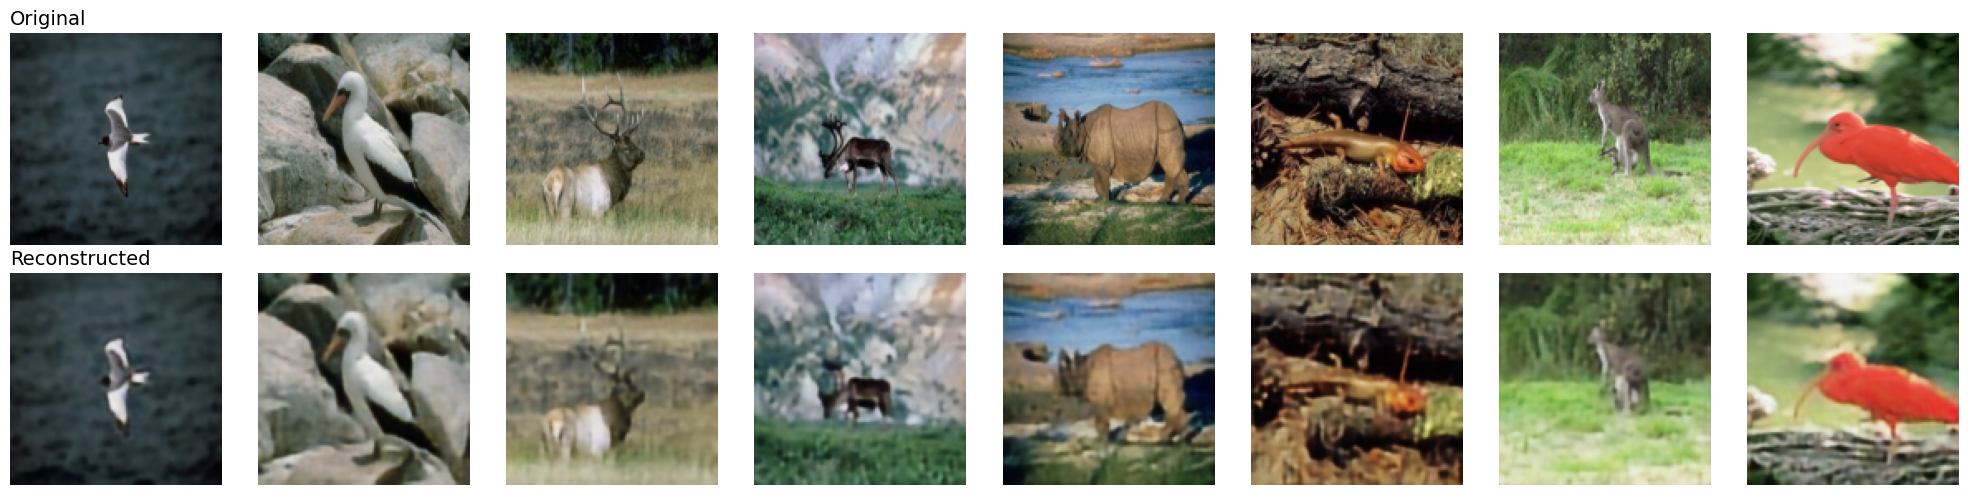

In [9]:
import matplotlib.pyplot as plt
import torch

# Reload best model
import autoencoder
model = autoencoder.ConvolutionalAutoencoder().to("cuda")
checkpoint = torch.load(training_args.checkpoint_path, map_location="cuda", weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Get a batch from validation set
from ae_dataset import create_ae_dataloaders
loaders = create_ae_dataloaders(training_args.splits_dir, image_size=128, batch_size=32, num_workers=0, seed=42)
batch = next(iter(loaders["validation"]))
images = batch["image"][:8].to("cuda")

with torch.no_grad():
    reconstructions = model(images)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i in range(8):
    original = images[i].cpu().permute(1, 2, 0).numpy().clip(0, 1)
    recon = reconstructions[i].cpu().permute(1, 2, 0).numpy().clip(0, 1)
    axes[0, i].imshow(original)
    axes[0, i].axis("off")
    axes[1, i].imshow(recon)
    axes[1, i].axis("off")

axes[0, 0].set_title("Original", loc="left", fontsize=14)
axes[1, 0].set_title("Reconstructed", loc="left", fontsize=14)
plt.tight_layout()
plt.show()